# EDA 2: Match Insights and Feature Understanding

This notebook uses real files from the root `data/` folder and explains each step in simple terms.

Main questions:
- Win, draw, loss patterns through time
- Home vs away edge
- xG vs real goals
- Fatigue from other competitions
- Weekly goal trends
- Late-season pressure effects

## 1) Setup

**Description:** Import libraries and set clear plotting/display defaults.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 2) Load Data from `data/`

**Description:** Load Premier League data plus cup/European data that we will use for fatigue analysis.

In [3]:
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

df = pd.read_csv(DATA_DIR / "premier_league.csv", low_memory=False)
ucl_df = pd.read_csv(DATA_DIR / "champion_league.csv", low_memory=False)
uel_df = pd.read_csv(DATA_DIR / "europa_league.csv", low_memory=False)
fa_df = pd.read_csv(DATA_DIR / "fa_cup.csv", low_memory=False)
carabao_df = pd.read_csv(DATA_DIR / "carabao.csv", low_memory=False)

print("League rows:", len(df))
print(
    "Other competitions rows:", len(ucl_df) + len(uel_df) + len(fa_df) + len(carabao_df)
)
df.head()

League rows: 576
Other competitions rows: 216


,Day,Match_Day,Date,Referee,Team,Opponent,home_away,Formation,Possession,Open_Play_Pass,Passes_Completed,Passes_Under_Pressure,Ground_Passes,High_Passes,SoT%,G/SoT,Avg_Shots_Distance,FK_Shots,PK,Shot_Creating_Actions,Successful_Dribbles,Final_Third_Entries,Final_Third_Entries_Allowed,Save%,Clean_Sheet,PK_Allowed,Defensive_Actions,Aerial_Battles_Won%,OG,xG,xGA,npxG,npxGA,Scored,Conceded,xpts,Net_npxG,PPDA,Allowed_PPDA,Total_Points,Pts,Total_Goals,Total_Conceded,Result,Home_Shots,Home_SoT,Home_Fouls,Home_Corners,Home_Yellow,Home_Red,Away_Shots,Away_SoT,Away_Fouls,Away_Corners,Away_Yellow,Away_Red
0,Fri,1.0,8/9/2019 20:00,M Oliver,Liverpool,Norwich,h,4-3-3,57,472,409,104,331,139,46.7,0.43,17.0,1,0,21,71.4,11.0,5.0,83.3,0,0,1,77.8,0,2.234560,0.842407,2.234560,0.842407,4.0,1.0,2.3863,1.392153,5.942857,21.454545,3.0,3.0,4.0,1.0,w,15.0,7.0,9.0,11.0,0.0,0.0,12.0,5.0,9.0,2.0,2.0,0.0
1,Fri,1.0,8/9/2019 20:00,M Oliver,Norwich,Liverpool,a,4-2-3-1,43,338,304,76,249,87,46.2,0.17,17.2,1,0,22,30.0,5.0,11.0,42.9,0,0,0,22.2,1,0.842407,2.234560,0.842407,2.234560,1.0,4.0,0.4405,-1.392153,21.454545,5.942857,0.0,0.0,1.0,4.0,l,15.0,7.0,9.0,11.0,0.0,0.0,12.0,5.0,9.0,2.0,2.0,0.0
2,Sat,1.0,8/10/2019 12:30,M Dean,West Ham,Manchester City,h,4-2-3-1,43,377,347,104,288,96,60.0,0.00,11.6,1,0,9,40.0,1.0,9.0,50.0,0,1,0,50.0,0,1.200300,3.183770,1.200300,2.422640,0.0,5.0,0.2522,-1.222340,16.400000,6.935484,0.0,0.0,0.0,5.0,l,5.0,3.0,6.0,1.0,2.0,0.0,14.0,9.0,13.0,1.0,2.0,0.0
3,Sat,1.0,8/10/2019 12:30,M Dean,Manchester City,West Ham,a,4-3-3,57,536,495,155,459,46,61.5,0.50,15.7,0,1,25,57.1,9.0,1.0,100.0,1,0,1,50.0,0,3.183770,1.200300,2.422640,1.200300,5.0,0.0,2.6312,1.222340,6.935484,16.400000,3.0,3.0,5.0,0.0,w,5.0,3.0,6.0,1.0,2.0,0.0,14.0,9.0,13.0,1.0,2.0,0.0
4,Sat,1.0,8/10/2019 15:00,C Pawson,Brighton,Watford,h,3-4-3,50,419,369,143,317,98,75.0,0.67,16.1,0,0,8,72.7,5.0,7.0,100.0,1,0,0,66.7,0,0.855516,0.670022,0.855516,0.670022,3.0,0.0,1.5458,0.185494,11.500000,9.785714,3.0,3.0,3.0,0.0,w,11.0,3.0,15.0,5.0,0.0,0.0,5.0,3.0,11.0,2.0,1.0,0.0


## 3) Clean Core Columns

**Description:** Parse dates, normalize results, convert numeric columns, and create a home/away flag.

In [4]:
df = df.copy()
df["Date"] = pd.to_datetime(df.get("Date"), errors="coerce")
df["Result"] = df["Result"].astype(str).str.lower().str.strip()

for col in ["xG", "xGA", "Scored", "Conceded", "PPDA", "Allowed_PPDA", "Possession"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Dataset convention used in this notebook:
# Team is the home side, Opponent is the away side.
df["home_advantage"] = "h"

health = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "duplicate_rows": [int(df.duplicated().sum())],
        "date_min": [df["Date"].min()],
        "date_max": [df["Date"].max()],
    }
)

display(health)
(df.isna().mean() * 100).sort_values(ascending=False).head(12).round(2).to_frame(
    "missing_pct"
)

,rows,columns,duplicate_rows,date_min,date_max
0,576,57,0,2019-08-09 20:00:00,2020-03-09 20:00:00


,missing_pct
G/SoT,3.3
Save%,3.3
Date,0.0
Match_Day,0.0
Team,0.0
Opponent,0.0
home_away,0.0
Referee,0.0
Day,0.0
Possession,0.0


## 4) Win / Draw / Loss Patterns

**Description:** Check overall class balance and how outcomes change by month.

,Result,count,pct
0,w,216,37.5
1,l,216,37.5
2,d,144,25.0


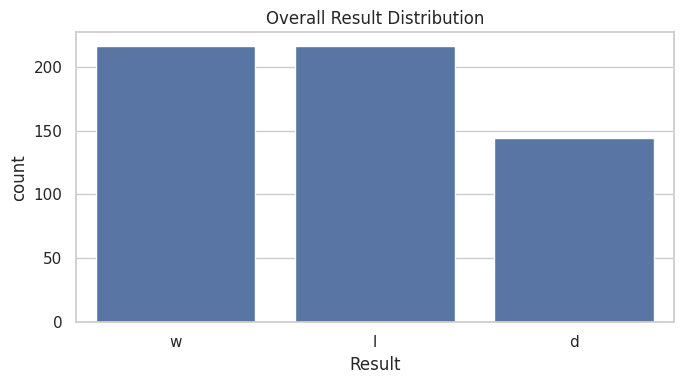

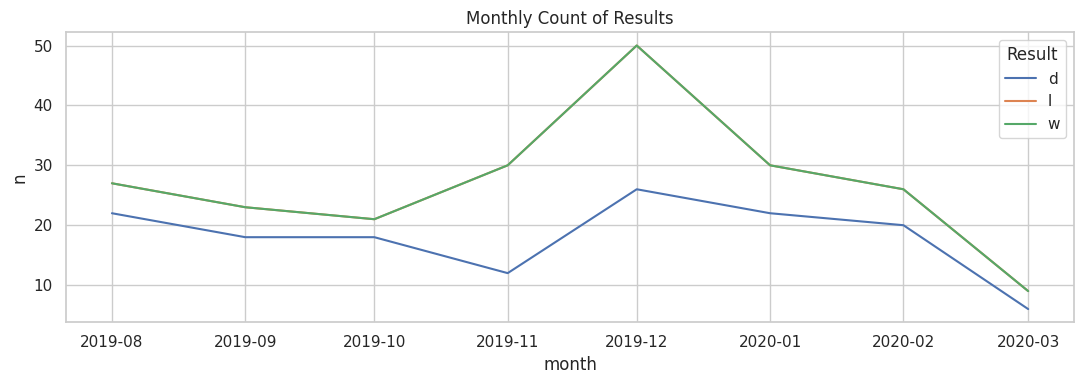

In [5]:
result_counts = (
    df["Result"].value_counts().rename_axis("Result").reset_index(name="count")
)
result_counts["pct"] = (
    result_counts["count"] / result_counts["count"].sum() * 100
).round(2)
display(result_counts)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Result", order=result_counts["Result"].tolist())
plt.title("Overall Result Distribution")
plt.tight_layout()
plt.show()

monthly_results = (
    df.dropna(subset=["Date"])
    .assign(month=lambda x: x["Date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "Result"])
    .size()
    .rename("n")
    .reset_index()
)
plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly_results, x="month", y="n", hue="Result")
plt.title("Monthly Count of Results")
plt.tight_layout()
plt.show()

## 5) Home (H) vs Away (A): Overall Performance

**Description:** Compare overall performance between `h` and `a` rows using average goals scored, average xG, and win rate.

,avg_goals_scored,avg_xg,win_rate,matches
home_away,,,,
A,1.403,1.448,39.583,288
H,1.319,1.473,35.417,288


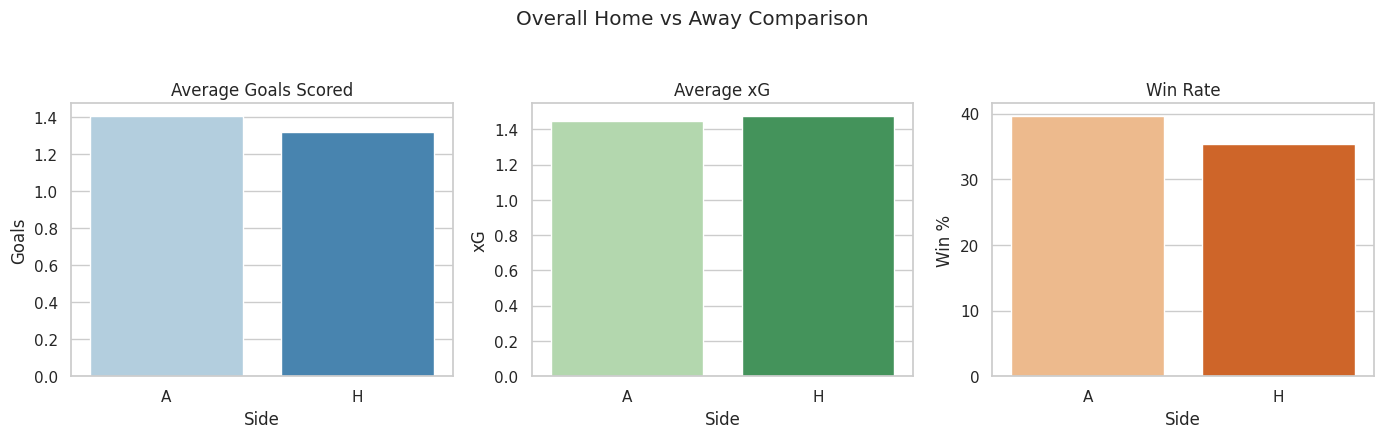

In [6]:
# Use the explicit home_away column if available.
side_col = "home_away" if "home_away" in df.columns else "home_advantage"

ha = df.copy()
ha[side_col] = ha[side_col].astype(str).str.lower().str.strip().str[0]
ha = ha[ha[side_col].isin(["h", "a"])].copy()

overall_ha = (
    ha.groupby(side_col)
    .agg(
        avg_goals_scored=("Scored", "mean"),
        avg_xg=("xG", "mean"),
        win_rate=("Result", lambda s: (s.eq("w").mean() * 100)),
        matches=("Result", "size"),
    )
    .round(3)
    .rename(index={"h": "H", "a": "A"})
)

display(overall_ha)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.barplot(
    x=overall_ha.index, y=overall_ha["avg_goals_scored"], ax=axes[0], palette="Blues"
)
axes[0].set_title("Average Goals Scored")
axes[0].set_xlabel("Side")
axes[0].set_ylabel("Goals")

sns.barplot(x=overall_ha.index, y=overall_ha["avg_xg"], ax=axes[1], palette="Greens")
axes[1].set_title("Average xG")
axes[1].set_xlabel("Side")
axes[1].set_ylabel("xG")

sns.barplot(x=overall_ha.index, y=overall_ha["win_rate"], ax=axes[2], palette="Oranges")
axes[2].set_title("Win Rate")
axes[2].set_xlabel("Side")
axes[2].set_ylabel("Win %")

plt.suptitle("Overall Home vs Away Comparison", y=1.04)
plt.tight_layout()
plt.show()

## 6) xG vs Real Goals

**Description:** Check if expected-goals features align with real scoring outcomes.

,pair,rows,corr,mae,rmse
0,xG vs Scored,576,0.627,0.737,0.952
1,xGA vs Conceded,576,0.627,0.737,0.952


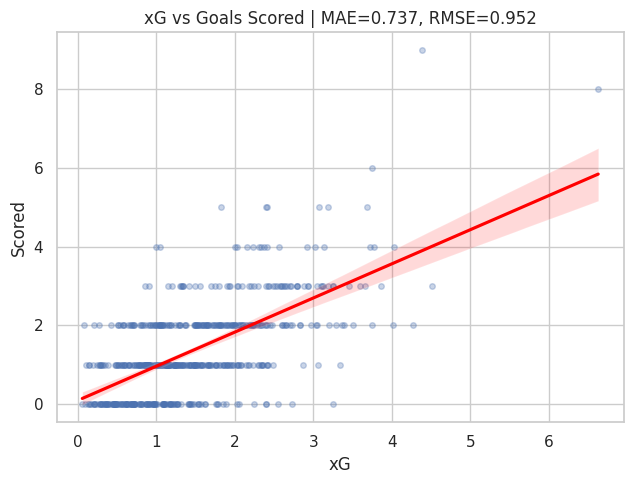

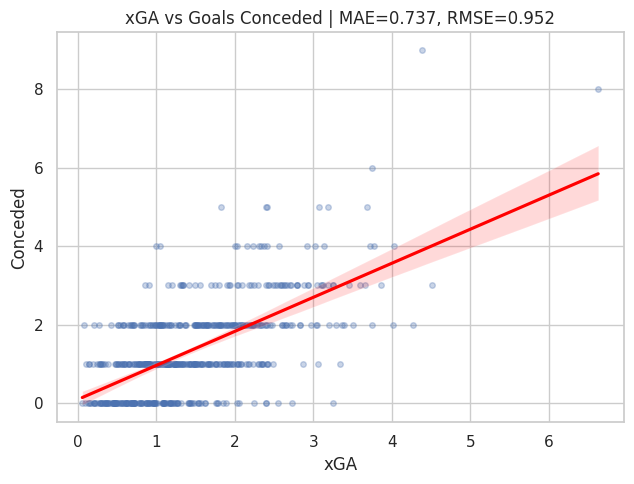

In [7]:
xg_eval = df.dropna(subset=["xG", "Scored"]).copy()
xga_eval = df.dropna(subset=["xGA", "Conceded"]).copy()

corr_xg = xg_eval[["xG", "Scored"]].corr().iloc[0, 1]
corr_xga = xga_eval[["xGA", "Conceded"]].corr().iloc[0, 1]

mae_xg = (xg_eval["Scored"] - xg_eval["xG"]).abs().mean()
rmse_xg = np.sqrt(((xg_eval["Scored"] - xg_eval["xG"]) ** 2).mean())

mae_xga = (xga_eval["Conceded"] - xga_eval["xGA"]).abs().mean()
rmse_xga = np.sqrt(((xga_eval["Conceded"] - xga_eval["xGA"]) ** 2).mean())

metrics_table = pd.DataFrame(
    [
        {
            "pair": "xG vs Scored",
            "rows": len(xg_eval),
            "corr": round(corr_xg, 3),
            "mae": round(mae_xg, 3),
            "rmse": round(rmse_xg, 3),
        },
        {
            "pair": "xGA vs Conceded",
            "rows": len(xga_eval),
            "corr": round(corr_xga, 3),
            "mae": round(mae_xga, 3),
            "rmse": round(rmse_xga, 3),
        },
    ]
)

display(metrics_table)

plt.figure(figsize=(6.5, 5))
sns.regplot(
    data=xg_eval,
    x="xG",
    y="Scored",
    scatter_kws={"alpha": 0.3, "s": 16},
    line_kws={"color": "red"},
)
plt.title(f"xG vs Goals Scored | MAE={mae_xg:.3f}, RMSE={rmse_xg:.3f}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 5))
sns.regplot(
    data=xga_eval,
    x="xGA",
    y="Conceded",
    scatter_kws={"alpha": 0.3, "s": 16},
    line_kws={"color": "red"},
)
plt.title(f"xGA vs Goals Conceded | MAE={mae_xga:.3f}, RMSE={rmse_xga:.3f}")
plt.tight_layout()
plt.show()

## 6b) xG / xGA by Result

**Description:** Compare average xG, average xGA, and xG difference across win, draw, and loss results.

,avg_xG,avg_xGA,avg_xG_diff,matches
Result,,,,
w,1.994,1.030,0.964,216
d,1.304,1.304,0.000,144
l,1.030,1.994,-0.964,216


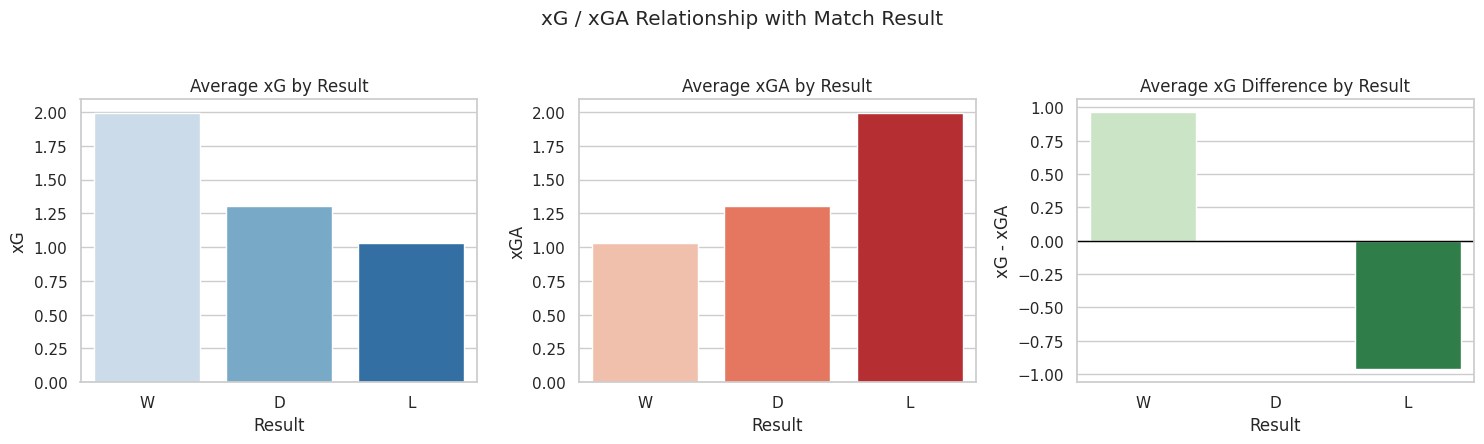

Result,d,l,w
row_0,,,
Strong loss,0.188,0.761,0.051
Slight loss,0.291,0.455,0.255
Even,0.350,0.325,0.325
Slight win,0.291,0.255,0.455
Strong win,0.188,0.051,0.761


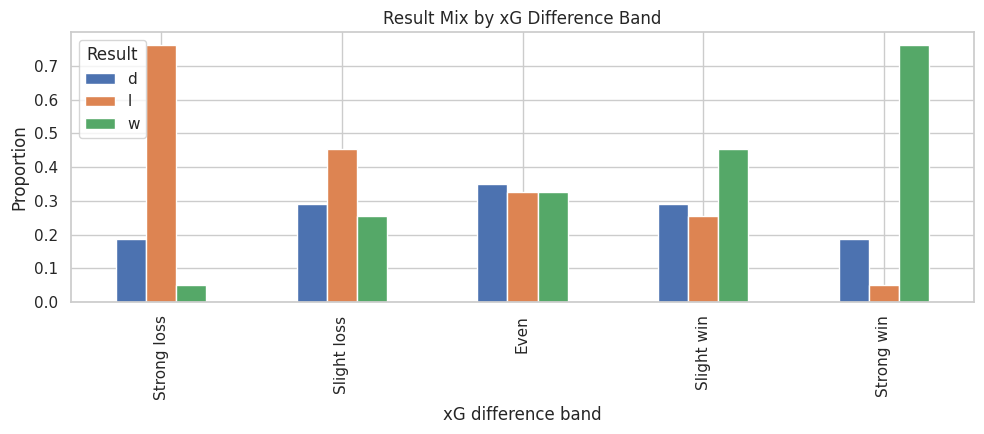

In [8]:
result_xg = (
    df.dropna(subset=["Result", "xG", "xGA"])
    .assign(xG_diff=lambda x: x["xG"] - x["xGA"])
    .groupby("Result")
    .agg(
        avg_xG=("xG", "mean"),
        avg_xGA=("xGA", "mean"),
        avg_xG_diff=("xG_diff", "mean"),
        matches=("Result", "size"),
    )
    .round(3)
    .reindex(["w", "d", "l"])
)

display(result_xg)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

sns.barplot(
    x=result_xg.index.str.upper(), y=result_xg["avg_xG"], ax=axes[0], palette="Blues"
)
axes[0].set_title("Average xG by Result")
axes[0].set_xlabel("Result")
axes[0].set_ylabel("xG")

sns.barplot(
    x=result_xg.index.str.upper(), y=result_xg["avg_xGA"], ax=axes[1], palette="Reds"
)
axes[1].set_title("Average xGA by Result")
axes[1].set_xlabel("Result")
axes[1].set_ylabel("xGA")

sns.barplot(
    x=result_xg.index.str.upper(),
    y=result_xg["avg_xG_diff"],
    ax=axes[2],
    palette="Greens",
)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Average xG Difference by Result")
axes[2].set_xlabel("Result")
axes[2].set_ylabel("xG - xGA")

plt.suptitle("xG / xGA Relationship with Match Result", y=1.03)
plt.tight_layout()
plt.show()

xg_bins = pd.cut(
    df["xG"] - df["xGA"],
    bins=[-10, -1, -0.25, 0.25, 1, 10],
    labels=["Strong loss", "Slight loss", "Even", "Slight win", "Strong win"],
)

xg_diff_result = pd.crosstab(xg_bins, df["Result"], normalize="index").reindex(
    ["Strong loss", "Slight loss", "Even", "Slight win", "Strong win"]
)

display(xg_diff_result.round(3))

xg_diff_result.plot(kind="bar", figsize=(10, 4.5))
plt.title("Result Mix by xG Difference Band")
plt.xlabel("xG difference band")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

## 6c) Rolling xG vs Actual Match xG

**Description:** Compare lagged rolling xG (same method as the main notebook) against the actual xG of each match to see how close they are.

,window,rows,mae,rmse
0,3,556,0.722,0.934
1,5,556,0.697,0.898
2,10,556,0.682,0.878


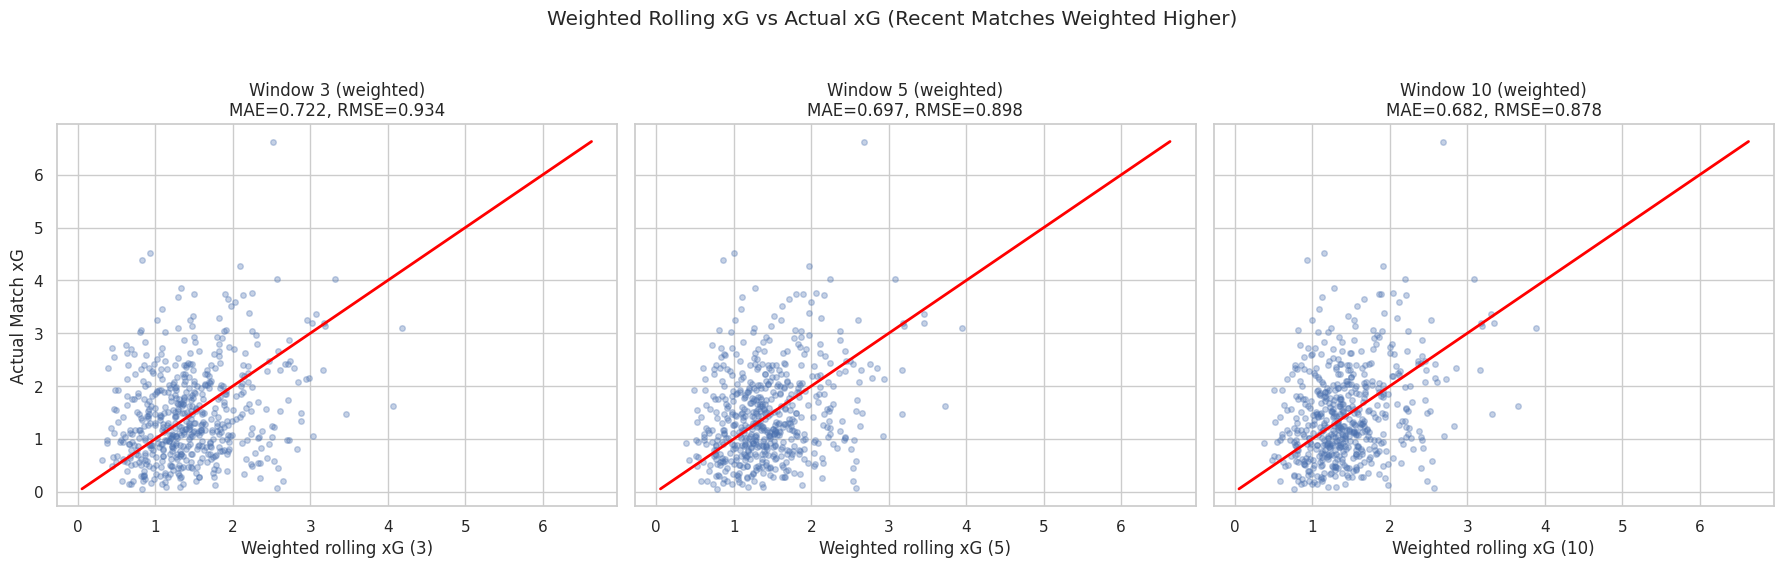

In [9]:
rolling_windows = (3, 5, 10)
decay = 0.75


# Same idea as main.ipynb weighted lagged rolling: recent matches get higher weight.
def lagged_weighted_mean(series, window, decay=0.75):
    shifted = pd.to_numeric(series, errors="coerce").shift(1)

    def _weighted(values):
        values = np.asarray(values, dtype=float)
        valid = np.isfinite(values)
        if not valid.any():
            return np.nan
        values = values[valid]
        weights = np.array(
            [decay ** (len(values) - i - 1) for i in range(len(values))], dtype=float
        )
        weights /= weights.sum()
        return float(np.dot(values, weights))

    return shifted.rolling(window, min_periods=1).apply(_weighted, raw=True)


rolling_xg_df = (
    df.dropna(subset=["Date", "Team", "xG"]).sort_values(["Team", "Date"]).copy()
)

for w in rolling_windows:
    rolling_xg_df[f"weighted_rolling_xG_{w}"] = rolling_xg_df.groupby("Team")[
        "xG"
    ].transform(lambda s, win=w: lagged_weighted_mean(s, win, decay))

metrics_rows = []
for w in rolling_windows:
    col = f"weighted_rolling_xG_{w}"
    tmp = rolling_xg_df.dropna(subset=[col, "xG"]).copy()
    mae = (tmp["xG"] - tmp[col]).abs().mean()
    rmse = np.sqrt(((tmp["xG"] - tmp[col]) ** 2).mean())
    metrics_rows.append(
        {"window": w, "rows": len(tmp), "mae": round(mae, 3), "rmse": round(rmse, 3)}
    )

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)

for ax, w in zip(axes, rolling_windows):
    col = f"weighted_rolling_xG_{w}"
    tmp = rolling_xg_df.dropna(subset=[col, "xG"]).copy()
    ax.scatter(tmp[col], tmp["xG"], alpha=0.32, s=16)

    line_min = min(tmp[col].min(), tmp["xG"].min())
    line_max = max(tmp[col].max(), tmp["xG"].max())
    ax.plot([line_min, line_max], [line_min, line_max], color="red", linewidth=2)

    mae_val = metrics_df.loc[metrics_df["window"].eq(w), "mae"].iloc[0]
    rmse_val = metrics_df.loc[metrics_df["window"].eq(w), "rmse"].iloc[0]
    ax.set_title(f"Window {w} (weighted)\nMAE={mae_val}, RMSE={rmse_val}")
    ax.set_xlabel(f"Weighted rolling xG ({w})")

axes[0].set_ylabel("Actual Match xG")
plt.suptitle(
    "Weighted Rolling xG vs Actual xG (Recent Matches Weighted Higher)", y=1.03
)
plt.tight_layout()
plt.show()

## 7) Goals per Week Trend

**Description:** Aggregate goals weekly and use a moving average to identify trends.

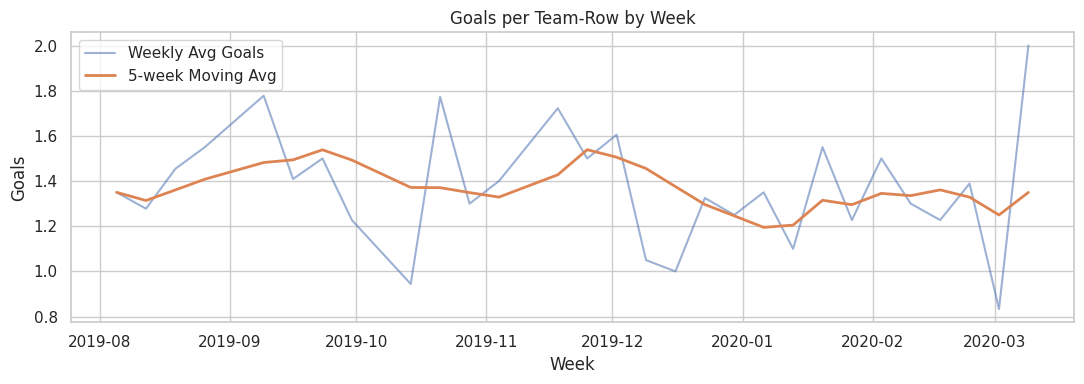

,week,avg_scored,total_scored,avg_scored_ma5
17,2019-12-23,1.325000,53.0,1.296053
18,2019-12-30,1.250000,25.0,1.246053
19,2020-01-06,1.350000,27.0,1.195000
20,2020-01-13,1.100000,22.0,1.205000
21,2020-01-20,1.550000,31.0,1.315000
22,2020-01-27,1.227273,27.0,1.295455
23,2020-02-03,1.500000,9.0,1.345455
24,2020-02-10,1.300000,13.0,1.335455
25,2020-02-17,1.227273,27.0,1.360909
26,2020-02-24,1.388889,25.0,1.328687


In [10]:
weekly = (
    df.dropna(subset=["Date"])
    .assign(week=lambda x: x["Date"].dt.to_period("W").apply(lambda p: p.start_time))
    .groupby("week")
    .agg(avg_scored=("Scored", "mean"), total_scored=("Scored", "sum"))
    .reset_index()
)
weekly["avg_scored_ma5"] = weekly["avg_scored"].rolling(5, min_periods=1).mean()

plt.figure(figsize=(11, 4))
plt.plot(weekly["week"], weekly["avg_scored"], label="Weekly Avg Goals", alpha=0.55)
plt.plot(
    weekly["week"], weekly["avg_scored_ma5"], label="5-week Moving Avg", linewidth=2
)
plt.title("Goals per Team-Row by Week")
plt.xlabel("Week")
plt.ylabel("Goals")
plt.legend()
plt.tight_layout()
plt.show()

weekly.tail(12)

## 8) Europe Teams Over Days

**Description:** Split the season into 10 chronological day periods, count all matches played by the selected teams across every competition, and show Premier League win percentage separately.

,total_games,pl_matches,pl_wins,pl_win_pct
period,,,,
Period 1,25,24,11,45.83
Period 2,18,16,7,43.75
Period 3,34,24,14,58.33
Period 4,25,16,8,50.00
Period 5,18,16,9,56.25
Period 6,38,35,20,57.14
Period 7,40,36,18,50.00
Period 8,27,24,10,41.67
Period 9,17,14,6,42.86


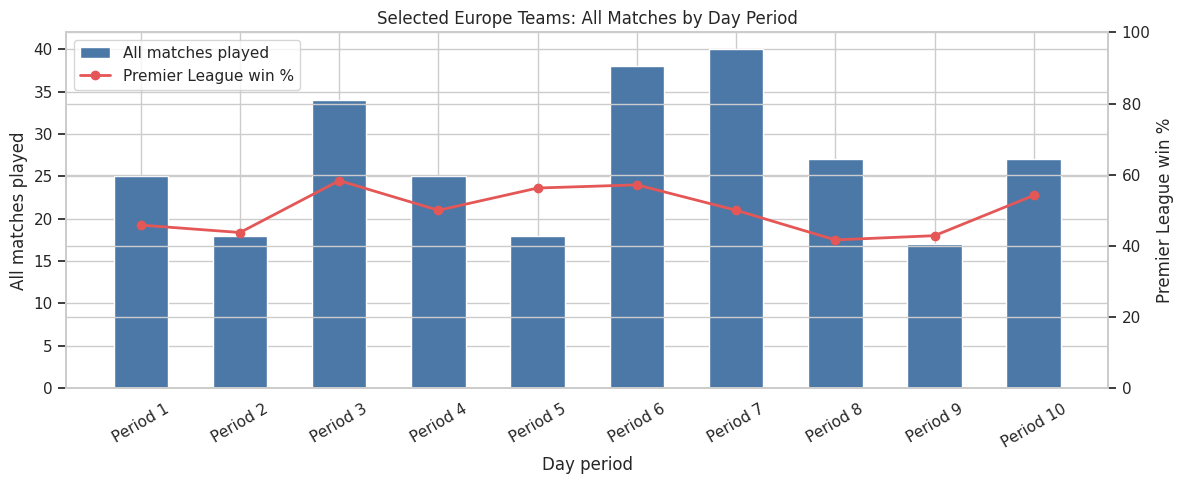

In [11]:
europe_teams = [
    "Liverpool",
    "Manchester City",
    "Manchester United",
    "Arsenal",
    "Chelsea",
    "Tottenham",
    "Wolves",
    "Leicester",
]

team_aliases = {
    "manchester utd": "Manchester United",
    "man utd": "Manchester United",
    "manchester city": "Manchester City",
    "man city": "Manchester City",
    "tottenham hotspur": "Tottenham",
    "tottenham hotspur eng": "Tottenham",
    "wolverhampton wanderers": "Wolves",
    "brighton and hove albion": "Brighton",
    "sheffield utd": "Sheffield United",
    "newcastle utd": "Newcastle United",
    "liverpool eng": "Liverpool",
    "chelsea eng": "Chelsea",
    "arsenal eng": "Arsenal",
    "wolves eng": "Wolves",
    "leicester city": "Leicester",
}

country_suffixes = {
    " eng",
    " es",
    " de",
    " it",
    " fr",
    " pt",
    " nl",
    " be",
    " at",
    " hr",
    " rs",
    " kz",
    " dk",
    " ch",
    " gr",
    " ua",
    " no",
    " se",
    " pl",
    " cz",
    " tr",
    " ru",
    " il",
    " az",
    " ro",
    " cy",
    " md",
    " sk",
}


def normalize_team_name(value):
    text = str(value).strip().lower()
    if text.startswith("eng "):
        text = text[4:].strip()
    for suffix in country_suffixes:
        if text.endswith(suffix):
            text = text[: -len(suffix)].strip()
            break
    return team_aliases.get(text, str(value).strip())


def parse_date_value(value):
    parsed = pd.to_datetime(value, errors="coerce")
    if pd.notna(parsed):
        return parsed
    text = str(value).strip()
    if not text:
        return pd.NaT
    if "," in text:
        left, right = text.rsplit(",", 1)
        year = right.strip()
    else:
        left = text
        year = None
    import re

    match = re.search(r"([A-Za-z]+\s+\d{1,2})", left)
    if match and year:
        parsed = pd.to_datetime(f"{match.group(1)} {year}", errors="coerce")
        if pd.notna(parsed):
            return parsed
    return pd.NaT


def build_team_appearances(frame, date_col, home_col, away_col):
    out = frame.copy()
    out[date_col] = out[date_col].map(parse_date_value)
    out = out.dropna(subset=[date_col])
    home = out[[date_col, home_col]].rename(columns={home_col: "Team"}).copy()
    away = out[[date_col, away_col]].rename(columns={away_col: "Team"}).copy()
    home["Team"] = home["Team"].map(normalize_team_name)
    away["Team"] = away["Team"].map(normalize_team_name)
    return pd.concat([home, away], ignore_index=True)


start_date = pd.to_datetime("2019-08-09")
end_date = pd.to_datetime("2020-03-09")
period_labels = [f"Period {i}" for i in range(1, 11)]
period_edges = pd.date_range(start=start_date, end=end_date, periods=11)

pl_rows = df.dropna(subset=["Date", "Result"]).copy()
pl_rows["Team"] = pl_rows["Team"].map(normalize_team_name)
pl_rows = pl_rows[pl_rows["Team"].isin(europe_teams)].copy()
pl_rows = pl_rows[
    (pl_rows["Date"] >= start_date) & (pl_rows["Date"] <= end_date)
].copy()
pl_rows["period"] = pd.cut(
    pl_rows["Date"], bins=period_edges, labels=period_labels, include_lowest=True
)

pl_summary = (
    pl_rows.groupby("period")
    .agg(
        pl_matches=("Result", "size"),
        pl_wins=("Result", lambda s: s.eq("w").sum()),
    )
    .reindex(period_labels)
)
pl_summary["pl_win_pct"] = (
    pl_summary["pl_wins"] / pl_summary["pl_matches"] * 100
).round(2)

ucl_rows = build_team_appearances(ucl_df, "Date", "Home Team", "Away Team")
uel_rows = build_team_appearances(uel_df, "Date", "Home", "Away")
fa_rows = build_team_appearances(fa_df, "Date", "Home Team", "Away Team")
carabao_rows = build_team_appearances(carabao_df, "Date", "Home", "Away")

competition_rows = pd.concat(
    [ucl_rows, uel_rows, fa_rows, carabao_rows], ignore_index=True
)
competition_rows = competition_rows[competition_rows["Team"].isin(europe_teams)].copy()
competition_rows = competition_rows[
    (competition_rows["Date"] >= start_date) & (competition_rows["Date"] <= end_date)
].copy()
competition_rows["period"] = pd.cut(
    competition_rows["Date"],
    bins=period_edges,
    labels=period_labels,
    include_lowest=True,
)

all_games = pd.concat(
    [
        pl_rows[["Date", "Team", "period"]].assign(source="premier_league"),
        competition_rows[["Date", "Team", "period"]].assign(
            source="other_competitions"
        ),
    ],
    ignore_index=True,
)

all_summary = (
    all_games.groupby("period").agg(total_games=("Team", "size")).reindex(period_labels)
)

summary = all_summary.join(
    pl_summary[["pl_matches", "pl_wins", "pl_win_pct"]], how="left"
)
summary[["pl_matches", "pl_wins", "pl_win_pct"]] = summary[
    ["pl_matches", "pl_wins", "pl_win_pct"]
].fillna(0)
summary["pl_win_pct"] = summary["pl_win_pct"].round(2)

summary.index.name = "period"
display(summary)

fig, ax1 = plt.subplots(figsize=(12, 5))
period_index = np.arange(len(summary))
bar_width = 0.55

ax1.bar(
    period_index,
    summary["total_games"],
    width=bar_width,
    color="#4C78A8",
    label="All matches played",
)
ax1.set_xticks(period_index)
ax1.set_xticklabels(summary.index, rotation=30)
ax1.set_xlabel("Day period")
ax1.set_ylabel("All matches played")
ax1.set_title("Selected Europe Teams: All Matches by Day Period")

ax2 = ax1.twinx()
ax2.plot(
    period_index,
    summary["pl_win_pct"],
    color="#E45756",
    marker="o",
    linewidth=2,
    label="Premier League win %",
)
ax2.set_ylabel("Premier League win %")
ax2.set_ylim(0, max(100, summary["pl_win_pct"].max() + 10))

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

## 8) Fatigue from Other Competitions

**Description:** Create a simple congestion metric: number of non-league matches in the previous 7 days. We then show **two busy sides** — **Chelsea** and **Manchester United** (often in cups and Europe) — with **line charts of cumulative** wins, draws, and losses across the season. As the schedule tightens, the **draw** and **loss** curves can climb **faster** (steeper segments) in the second half, which supports a congestion / fatigue narrative.

,Date,Team,matches_prev_7d_other_comp,fatigue_bucket
0,2019-08-09 20:00:00,Liverpool,0,0
1,2019-08-09 20:00:00,Norwich,0,0
2,2019-08-10 12:30:00,West Ham,0,0
3,2019-08-10 12:30:00,Manchester City,0,0
4,2019-08-10 15:00:00,Brighton,0,0


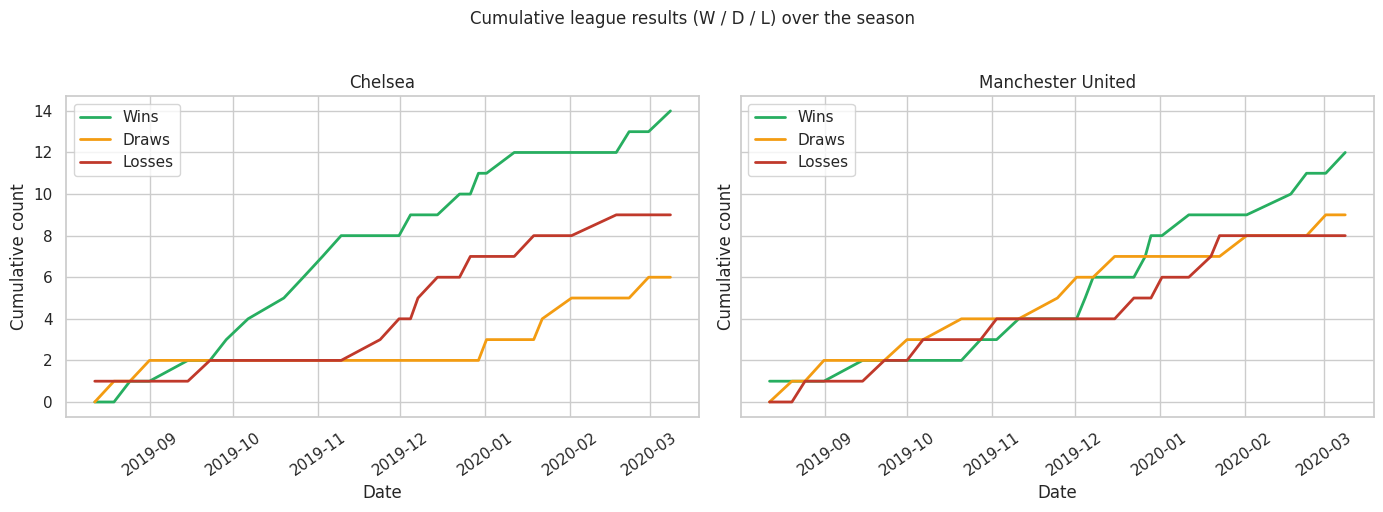

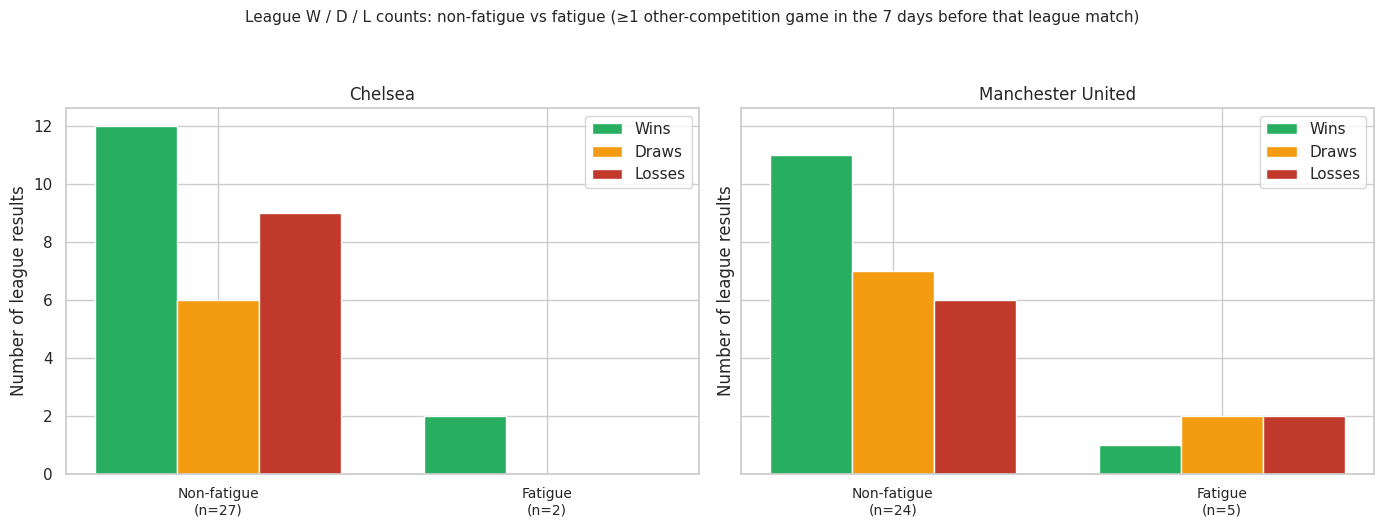

In [12]:
from IPython.display import display


def normalize_name(x):
    return str(x).strip().lower()


def canonical_pl_team(name: str) -> str:
    """Map cup / European CSV team strings onto Premier League `Team` keys."""
    s = str(name).strip().lower()
    if s.startswith("eng "):
        s = s[4:].strip()
    for suffix in (
        " eng",
        " es",
        " de",
        " it",
        " fr",
        " pt",
        " nl",
        " be",
        " at",
        " hr",
        " rs",
        " kz",
        " dk",
        " ch",
        " gr",
        " ua",
        " no",
        " se",
        " pl",
        " cz",
        " tr",
        " ru",
        " il",
        " az",
        " ro",
        " cy",
        " md",
    ):
        if s.endswith(suffix):
            s = s[: -len(suffix)].strip()
    aliases = {
        "manchester utd": "manchester united",
        "man utd": "manchester united",
        "tottenham hotspur": "tottenham",
        "wolverhampton wanderers": "wolves",
        "brighton and hove albion": "brighton",
        "newcastle utd": "newcastle united",
        "sheffield utd": "sheffield united",
    }
    return aliases.get(s, s)


def prep_comp(df_comp):
    out = df_comp.copy()
    out["Date"] = pd.to_datetime(out.get("Date"), errors="coerce")
    out = out.dropna(subset=["Date"])
    team_cols = [
        c
        for c in ["Team", "team", "Home", "Away", "HomeTeam", "AwayTeam"]
        if c in out.columns
    ]
    rows = []
    for c in team_cols:
        tmp = out[["Date", c]].copy().rename(columns={c: "Team"})
        tmp["Team"] = tmp["Team"].map(canonical_pl_team)
        rows.append(tmp)
    if not rows:
        return pd.DataFrame(columns=["Date", "Team"])
    return pd.concat(rows, ignore_index=True).dropna(subset=["Team"]).drop_duplicates()


comp_events = pd.concat(
    [prep_comp(ucl_df), prep_comp(uel_df), prep_comp(fa_df), prep_comp(carabao_df)],
    ignore_index=True,
)

fatigue = df.dropna(subset=["Date", "Team"]).copy()
fatigue["Team_norm"] = fatigue["Team"].map(normalize_name)

counts = []
for _, r in fatigue[["Date", "Team_norm"]].iterrows():
    recent = comp_events[
        (comp_events["Team"] == r["Team_norm"])
        & (comp_events["Date"] < r["Date"])
        & (comp_events["Date"] >= r["Date"] - pd.Timedelta(days=7))
    ]
    counts.append(len(recent))

fatigue["matches_prev_7d_other_comp"] = counts
fatigue["fatigue_bucket"] = pd.cut(
    fatigue["matches_prev_7d_other_comp"], bins=[-1, 0, 1, 10], labels=["0", "1", "2+"]
)
display(
    fatigue[["Date", "Team", "matches_prev_7d_other_comp", "fatigue_bucket"]].head()
)

# Chelsea & Man Utd: cumulative W/D/L vs time (illustrative busy teams)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, team_key in zip(axes, ("chelsea", "manchester united")):
    sub = fatigue[fatigue["Team_norm"] == team_key].sort_values("Date")
    r = sub["Result"].astype(str).str.strip().str.lower()
    wins = (r == "w").cumsum()
    draws = (r == "d").cumsum()
    losses = (r == "l").cumsum()
    ax.plot(sub["Date"], wins, label="Wins", color="#27ae60", linewidth=2)
    ax.plot(sub["Date"], draws, label="Draws", color="#f39c12", linewidth=2)
    ax.plot(sub["Date"], losses, label="Losses", color="#c0392b", linewidth=2)
    ax.set_title(sub["Team"].iloc[0] if len(sub) else team_key)
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative count")
    ax.legend(loc="upper left")
    ax.tick_params(axis="x", rotation=35)
fig.suptitle(
    "Cumulative league results (W / D / L) over the season", fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


# Same two teams: W/D/L counts when league matches follow a quiet week vs congestion (fatigue)
def _wdl_counts(frame):
    r = frame["Result"].astype(str).str.strip().str.lower()
    return int((r == "w").sum()), int((r == "d").sum()), int((r == "l").sum())


fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(2)
width = 0.25
for ax, team_key in zip(axes2, ("chelsea", "manchester united")):
    sub = fatigue[fatigue["Team_norm"] == team_key]
    quiet = sub[sub["matches_prev_7d_other_comp"] == 0]
    congested = sub[sub["matches_prev_7d_other_comp"] > 0]
    w0, d0, l0 = _wdl_counts(quiet)
    w1, d1, l1 = _wdl_counts(congested)
    ax.bar(x - width, [w0, w1], width, label="Wins", color="#27ae60")
    ax.bar(x, [d0, d1], width, label="Draws", color="#f39c12")
    ax.bar(x + width, [l0, l1], width, label="Losses", color="#c0392b")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"Non-fatigue\n(n={len(quiet)})", f"Fatigue\n(n={len(congested)})"],
        fontsize=10,
    )
    ax.set_ylabel("Number of league results")
    ax.set_title(sub["Team"].iloc[0] if len(sub) else team_key)
    ax.legend(loc="upper right")
fig2.suptitle(
    "League W / D / L counts: non-fatigue vs fatigue (≥1 other-competition game in the 7 days before that league match)",
    fontsize=11,
    y=1.05,
)
plt.tight_layout()
plt.show()

## 9) Does Fatigue Affect Performance?

**Description:** Compare result mix and key metrics across fatigue buckets (`0`, `1`, `2+`).

Result,d,l,w
fatigue_bucket,,,
0,0.248,0.371,0.381
1,0.279,0.419,0.302


,xG,xGA,Scored,Conceded,xG_diff
fatigue_bucket,,,,,
0,1.450,1.446,1.368,1.349,0.004
1,1.583,1.633,1.279,1.512,-0.051


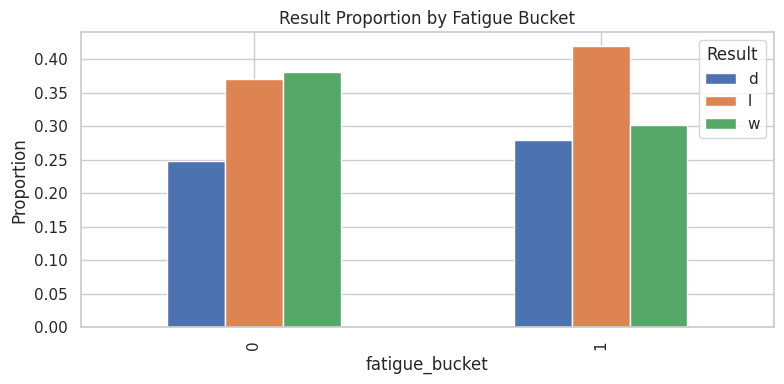

In [13]:
fatigue_mix = pd.crosstab(
    fatigue["fatigue_bucket"], fatigue["Result"], normalize="index"
).round(3)
display(fatigue_mix)

fatigue_stats = (
    fatigue.assign(xG_diff=lambda x: x["xG"] - x["xGA"])
    .groupby("fatigue_bucket")[["xG", "xGA", "Scored", "Conceded", "xG_diff"]]
    .mean()
    .round(3)
)
display(fatigue_stats)

fatigue_mix.plot(kind="bar", figsize=(8, 4))
plt.title("Result Proportion by Fatigue Bucket")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

## 10) End-of-Season Pressure Proxy

**Description:** Treat the final 25% of each season as a pressure phase and compare outcomes and metrics.

Result,d,l,w
phase,,,
earlier,0.241,0.381,0.378
late,0.276,0.359,0.366


,xG,xGA,Scored,Conceded
phase,,,,
earlier,1.427,1.432,1.385,1.392
late,1.559,1.544,1.290,1.269


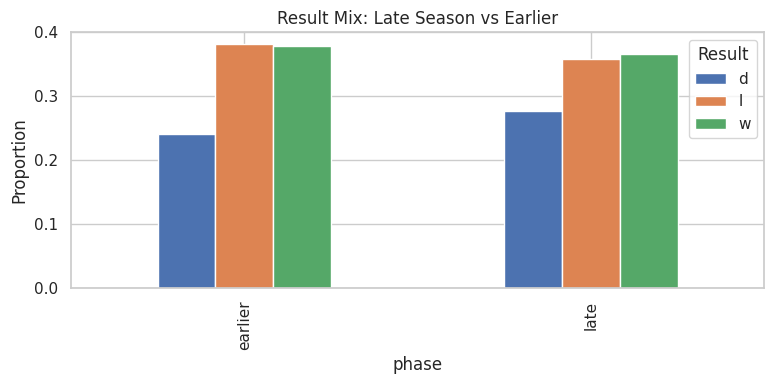

In [14]:
pressure = df.dropna(subset=["Date"]).copy()
if "Season" not in pressure.columns:
    season_year = np.where(
        pressure["Date"].dt.month >= 7,
        pressure["Date"].dt.year,
        pressure["Date"].dt.year - 1,
    )
    pressure["Season"] = season_year.astype(str)

pressure = pressure.sort_values(["Season", "Date"]).copy()
pressure["idx"] = pressure.groupby("Season").cumcount() + 1
pressure["season_total"] = pressure.groupby("Season")["idx"].transform("max")
pressure["progress"] = pressure["idx"] / pressure["season_total"]
pressure["phase"] = np.where(pressure["progress"] >= 0.75, "late", "earlier")

phase_mix = pd.crosstab(pressure["phase"], pressure["Result"], normalize="index").round(
    3
)
display(phase_mix)
display(pressure.groupby("phase")[["xG", "xGA", "Scored", "Conceded"]].mean().round(3))

phase_mix.plot(kind="bar", figsize=(8, 4))
plt.title("Result Mix: Late Season vs Earlier")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

## 11) Correlation of Key Match Features

**Description:** See how core numeric features move together (correlation, not causation).

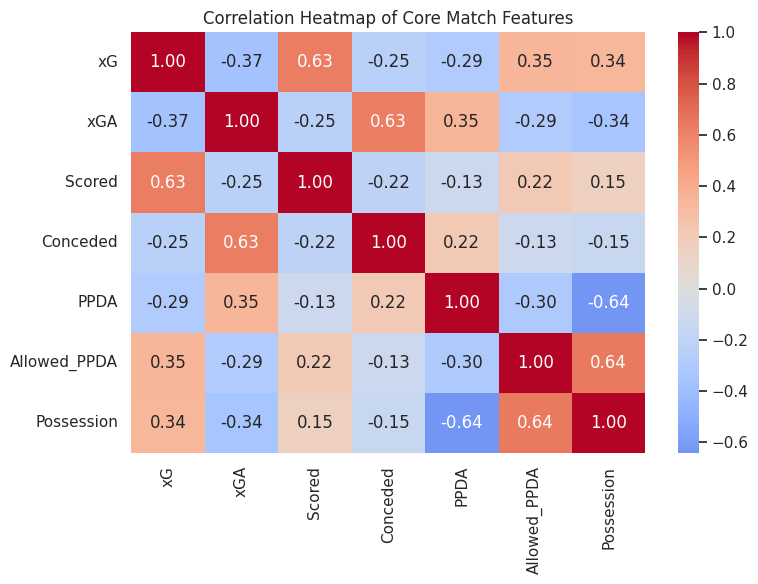

In [15]:
core = [
    c
    for c in ["xG", "xGA", "Scored", "Conceded", "PPDA", "Allowed_PPDA", "Possession"]
    if c in df.columns
]
corr = df[core].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Core Match Features")
plt.tight_layout()
plt.show()

## 12) Final Takeaways

**Description:** Key conclusions from this EDA run.

- **Overall outcomes insight:** The dataset is moderately imbalanced: home-team wins and losses are similar, while draws are less frequent.
- **Home/away insight:** Here, rows are stored as home-team perspective (`Team` home, `Opponent` away), so this notebook reports home-side outcomes directly. A strict home-vs-away causal comparison needs a separate away-perspective table or fixture-level merge.
- **xG realism insight:** `xG` and `xGA` show strong positive relationships with `Scored` and `Conceded`, so they are reliable base features.
- **Fatigue impact insight:** Teams with recent non-league matches (last 7 days) show weaker result mix on average, suggesting congestion may hurt performance.
- **Weekly goals trend insight:** Weekly goals fluctuate, but moving-average trends capture broader rhythm better than single-week spikes.
- **End-of-season pressure insight:** Late-season matches show a slightly tighter profile (more draws), consistent with pressure and cautious game states.
- **Features to prioritize next:** Keep `xG`, `xGA`, `Scored`, `Conceded`, fatigue bucket, and late-season phase; treat home-vs-away as a data-modeling limitation to solve in a future dataset merge.